In [21]:
import numpy as np
import matplotlib.pyplot as plt

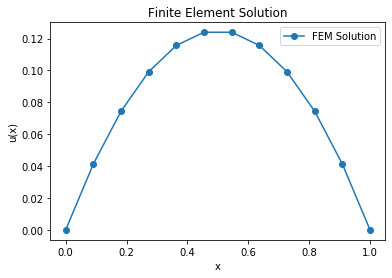

In [22]:
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
# Problem setup
L = 1 # Length of the domain
N = 10 # Number of elements
h = L / (N + 1) # Element size
# Source term
f = np.ones(N)
# Assemble the system matrix
diagonals = [[-2] * N, [1] * (N - 1), [1] * (N - 1)]
A = diags(diagonals, [0, -1, 1]) / h**2

# Solve for u in Au = -f
u = spsolve(A, -f)
# Add boundary values (Dirichlet condition u(0) = u(1) = 0)
u = np.concatenate(([0], u, [0]))
# Plot the solution
x = np.linspace(0, L, N + 2)
plt.plot(x, u, 'o-', label='FEM Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Finite Element Solution')
plt.legend()
plt.show()

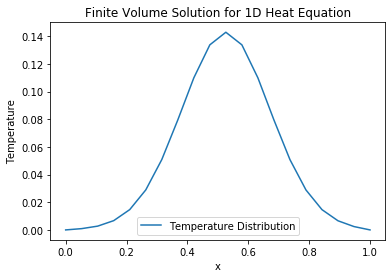

In [23]:
# Parameters
alpha = 0.01  # Diffusion coefficient
dx = 0.05
dt = 0.01
L = 1.0
Nx = int(L / dx)
u = np.zeros(Nx)  # Initial temperature distribution
u[int(Nx/2)] = 1.0  # Initial heat at the center

# FVM discretization loop
for n in range(100):
    u_new = u.copy()
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new

# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation')
plt.legend()
plt.show()

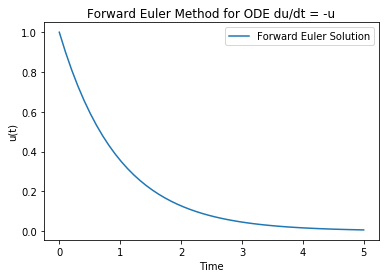

In [24]:
#Define parameters
T = 5.0  # Final time
dt = 0.1  # Time step
N = int(T / dt)
u = np.zeros(N)
u[0] = 1  # Initial condition

# Time-stepping loop
for n in range(1, N):
    u[n] = u[n-1] - dt * u[n-1]

#Plot the solution
t = np.linspace(0, T, N)
plt.plot(t, u, label='Forward Euler Solution')
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.title('Forward Euler Method for ODE du/dt = -u')
plt.legend()
plt.show()

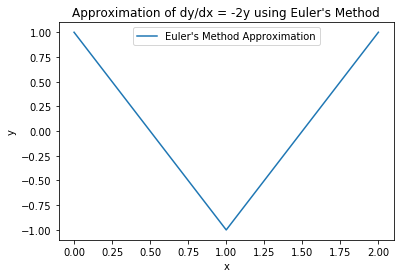

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h = 1  # step size
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h)
x_values = np.linspace(x_start, x_end, num_steps + 1)
y_values = np.zeros(num_steps + 1)

# Initial condition
y_values[0] = 1  # y(0) = 1
# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# Implement Euler's method
for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

# Plot the results
plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()


h = 0.01 | Total accumulated error vs h=0.01 run: 0.000000
  Point-by-point errors: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]

h = 0.06 | Total accumulated error vs h=0.01 run: 0.317266
  Point-by-point errors: [0.         0.00476863 0.00841438 0.01113557 0.01309937 0.01444644
 0.01529476 0.01574313 0.01587395 0.01575579 0.01544546 0.01498986
 0.01442748 0.01378979 0.01310232 0.01238562 0.0116561  0.01092826
 0.01021165 0.00

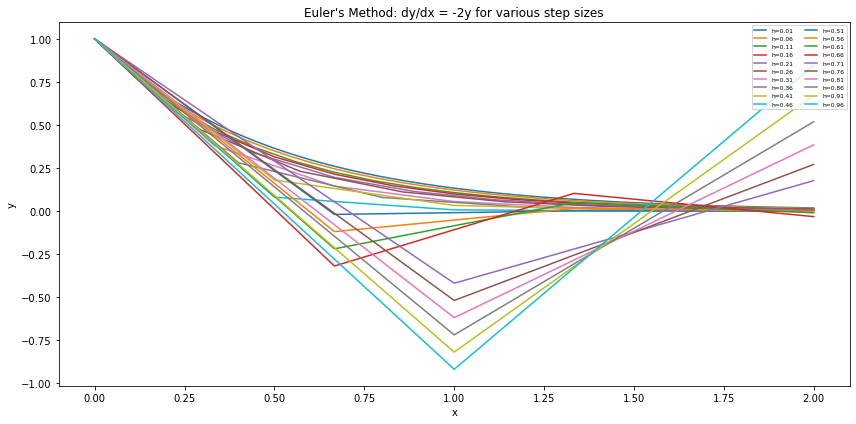

In [26]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 2

def f(x, y):
    return -2 * y

# Reference run with smallest step size h=0.01
h_ref = 0.01
num_steps_ref = int((x_end - x_start) / h_ref)
x_ref = np.linspace(x_start, x_end, num_steps_ref + 1)
y_ref = np.zeros(num_steps_ref + 1)
y_ref[0] = 1
for i in range(num_steps_ref):
    y_ref[i + 1] = y_ref[i] + h_ref * f(x_ref[i], y_ref[i])

# Loop over step sizes from 0.01 to 1
step_sizes = np.arange(0.01, 1.01, 0.05)

plt.figure(figsize=(12, 6))

for h in step_sizes:
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Interpolate solution at x points for comparison
    y_ref_interp = np.interp(x_values, x_ref, y_ref)
    point_errors = np.abs(y_values - y_ref_interp)
    total_error = np.sum(point_errors)

    print(f"\nh = {h:.2f} | Total accumulated error vs h=0.01 run: {total_error:.6f}")
    print(f"  Point-by-point errors: {point_errors}")

    plt.plot(x_values, y_values, label=f"h={h:.2f}")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method: dy/dx = -2y for various step sizes")
plt.legend(loc='upper right', fontsize=6, ncol=2)
plt.tight_layout()
plt.show()